# Task 2: End-to-End ML Pipeline — Customer Churn Prediction
**DevelopersHub Corporation — AI/ML Engineering Internship**

---

## Problem Statement
Customer churn — when a customer stops using a service — is a critical business problem for telecom companies. This notebook builds a **production-ready, reusable ML pipeline** that predicts which customers are likely to churn, enabling the business to intervene early.

## Objective
- Preprocess the Telco Churn dataset using `scikit-learn` Pipeline API
- Train Logistic Regression and Random Forest classifiers
- Tune hyperparameters using `GridSearchCV`
- Evaluate using Accuracy, F1-Score, and ROC-AUC
- Export the final pipeline using `joblib`

---

## Section 1 — Installations & Imports

In [1]:
# Uncomment if running in Google Colab
# !pip install scikit-learn pandas numpy matplotlib seaborn joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pipeline & Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation & Tuning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

# Export
import joblib
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All libraries imported successfully.')

Matplotlib is building the font cache; this may take a moment.


All libraries imported successfully.


---
## Section 2 — Dataset Loading & Preprocessing

**Dataset:** Telco Customer Churn — [Kaggle Link](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
Place `WA_Fn-UseC_-Telco-Customer-Churn.csv` in the same directory as this notebook.

In [2]:
# ── Load Dataset ─────────────────────────────────────────────
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Dataset shape: {df.shape}')
print(f'\nColumn names:\n{df.columns.tolist()}')
df.head()

Dataset shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# ── Basic Info ───────────────────────────────────────────────
print('Data Types:')
print(df.dtypes)
print(f'\nMissing values per column:')
print(df.isnull().sum())
print(f'\nTarget Distribution:')
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Paperl

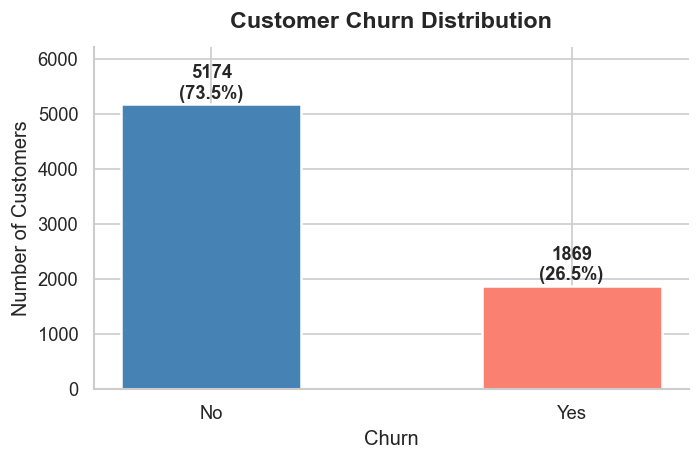

Observation: ~26% customers churned — moderately imbalanced dataset.
This is why we use F1-Score as the primary metric, not just Accuracy.


In [4]:
# ── Plot 1: Churn Distribution ───────────────────────────────
# Required to understand the class imbalance in the target variable

fig, ax = plt.subplots(figsize=(6, 4))
counts = df['Churn'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['steelblue', 'salmon'],
              edgecolor='white', linewidth=1.5, width=0.5)

# Add count + percentage labels on bars
total = len(df)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 40,
            f'{count}\n({count/total*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Churn', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_ylim(0, counts.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.savefig('churn_distribution.png', bbox_inches='tight')
plt.show()

print('Observation: ~26% customers churned — moderately imbalanced dataset.')
print('This is why we use F1-Score as the primary metric, not just Accuracy.')

In [5]:
# ── Fix Known Data Issues ────────────────────────────────────

# TotalCharges contains whitespace strings instead of NaN — convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop customerID — it's a unique identifier with no predictive value
df.drop('customerID', axis=1, inplace=True)

# Encode target: Yes → 1, No → 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('Data types fixed.')
print(f'Missing values after fix:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
print(f'\nTarget encoded: {df["Churn"].unique()}')

Data types fixed.
Missing values after fix:
TotalCharges    11
dtype: int64

Target encoded: [0 1]


In [6]:
# ── Separate Features and Target ────────────────────────────
X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify column types for the ColumnTransformer
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = X.select_dtypes(include=np.number).columns.tolist()

print(f'Numerical features  ({len(numerical_cols)}): {numerical_cols}')
print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')

Numerical features  (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [7]:
# ── Train / Test Split ───────────────────────────────────────
# stratify=y ensures the churn ratio is preserved in both splits

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set : {X_train.shape}')
print(f'Test set     : {X_test.shape}')
print(f'\nChurn rate in train : {y_train.mean():.3f}')
print(f'Churn rate in test  : {y_test.mean():.3f}')

Training set : (5634, 19)
Test set     : (1409, 19)

Churn rate in train : 0.265
Churn rate in test  : 0.265


---
## Section 3 — Pipeline Construction

We use `ColumnTransformer` to apply different transformations to numerical and categorical columns, then wrap everything in a `Pipeline` together with the classifier.  
This ensures **no data leakage** — the scaler and encoder only learn from training data.

In [8]:
# ── Sub-pipeline: Numerical Features ────────────────────────
# Step 1: Fill missing values with the column median
# Step 2: Scale to mean=0, std=1 (required for Logistic Regression)
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# ── Sub-pipeline: Categorical Features ──────────────────────
# Step 1: Fill missing values with the most frequent value
# Step 2: One-hot encode — converts string categories to 0/1 columns
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])

# ── ColumnTransformer: Routes each column to the right pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

print('Preprocessor constructed successfully.')

Preprocessor constructed successfully.


In [9]:
# ── Full Pipeline 1: Logistic Regression (Baseline) ─────────
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(random_state=42, max_iter=1000))
])

# ── Full Pipeline 2: Random Forest ──────────────────────────
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(random_state=42))
])

print('Both pipelines created.')
print('\nLogistic Regression Pipeline structure:')
print(pipeline_lr)

Both pipelines created.

Logistic Regression Pipeline structure:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                        

---
## Section 4 — Model Training & Hyperparameter Tuning

In [10]:
# ── Train Logistic Regression (Baseline) ────────────────────
pipeline_lr.fit(X_train, y_train)
y_pred_lr   = pipeline_lr.predict(X_test)
y_proba_lr  = pipeline_lr.predict_proba(X_test)[:, 1]

print('Logistic Regression trained.')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'  F1-Score : {f1_score(y_test, y_pred_lr):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, y_proba_lr):.4f}')

Logistic Regression trained.
  Accuracy : 0.8055
  F1-Score : 0.6040
  ROC-AUC  : 0.8419


In [11]:
# ── GridSearchCV on Random Forest ───────────────────────────
# NOTE: Inside a Pipeline, prefix parameter names with 'classifier__'

param_grid = {
    'classifier__n_estimators':    [100, 200],
    'classifier__max_depth':       [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    pipeline_rf,
    param_grid,
    cv=5,            # 5-fold cross-validation
    scoring='f1',    # optimise for F1 — more robust than accuracy on imbalanced data
    n_jobs=-1,       # use all available CPU cores
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f'\nGridSearch complete.')
print(f'Best parameters : {grid_search.best_params_}')
print(f'Best CV F1 Score: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

GridSearch complete.
Best parameters : {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV F1 Score: 0.5715


In [12]:
# ── Evaluate Best Random Forest ──────────────────────────────
best_rf     = grid_search.best_estimator_
y_pred_rf   = best_rf.predict(X_test)
y_proba_rf  = best_rf.predict_proba(X_test)[:, 1]

print('Random Forest (Tuned) — Test Set Results')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  F1-Score : {f1_score(y_test, y_pred_rf):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, y_proba_rf):.4f}')
print(f'\nClassification Report:\n')
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

Random Forest (Tuned) — Test Set Results
  Accuracy : 0.7999
  F1-Score : 0.5778
  ROC-AUC  : 0.8385

Classification Report:

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



---
## Section 5 — Evaluation with Metrics & Visualizations

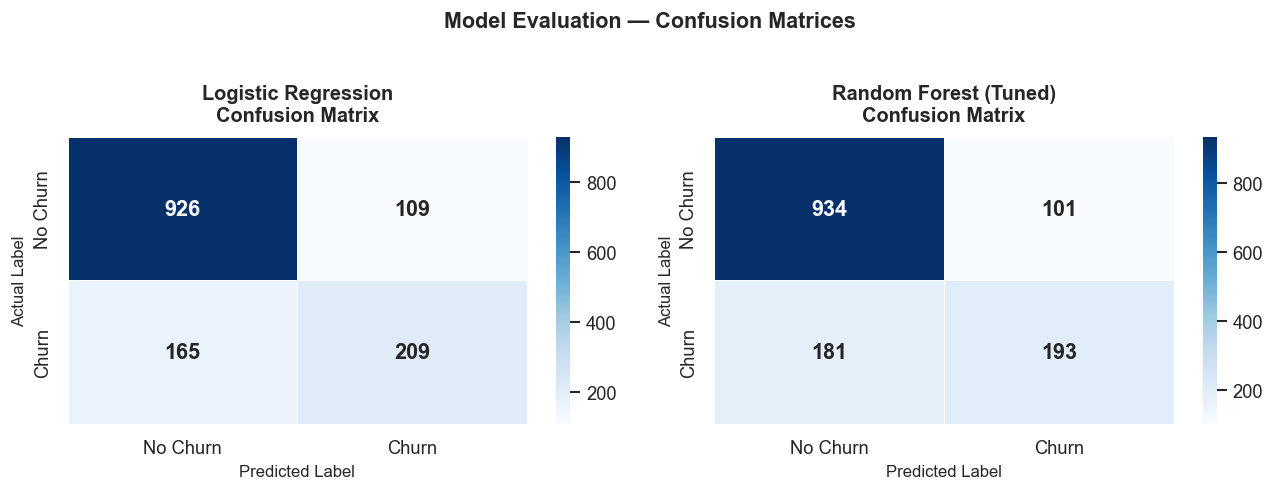

In [13]:
# ── Plot 2: Confusion Matrices ───────────────────────────────
# Shows True Positives, True Negatives, False Positives, False Negatives

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

models = [
    ('Logistic Regression',       y_pred_lr),
    ('Random Forest (Tuned)',      y_pred_rf)
]

for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['No Churn', 'Churn'],
        yticklabels=['No Churn', 'Churn'],
        linewidths=0.5, linecolor='white',
        annot_kws={'size': 13, 'weight': 'bold'}
    )
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Actual Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)

plt.suptitle('Model Evaluation — Confusion Matrices', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

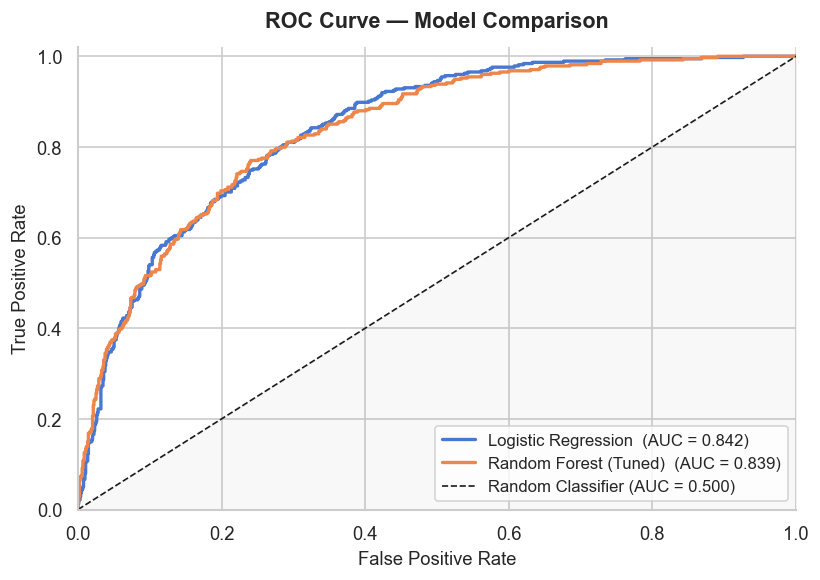

Observation: Both models significantly outperform a random baseline.
Random Forest achieves a marginally higher AUC after tuning.


In [14]:
# ── Plot 3: ROC Curve Comparison ─────────────────────────────
# Measures how well each model separates churners from non-churners
# Closer to top-left corner = better model

fig, ax = plt.subplots(figsize=(7, 5))

for name, model, y_proba in [
    ('Logistic Regression',  pipeline_lr, y_proba_lr),
    ('Random Forest (Tuned)', best_rf,    y_proba_rf)
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name}  (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — Model Comparison', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
sns.despine()
plt.tight_layout()
plt.savefig('roc_curve.png', bbox_inches='tight')
plt.show()

print('Observation: Both models significantly outperform a random baseline.')
print('Random Forest achieves a marginally higher AUC after tuning.')

---
## Section 6 — Model Export with joblib

In [15]:
# ── Save the Best Pipeline ───────────────────────────────────
# joblib serialises the entire pipeline — preprocessor + trained model

joblib.dump(best_rf, 'pipeline_model.joblib')
print('Pipeline saved as pipeline_model.joblib')

# ── Verify: Load and Predict ─────────────────────────────────
loaded_pipeline = joblib.load('pipeline_model.joblib')

sample = X_test.iloc[:5]
preds  = loaded_pipeline.predict(sample)
probas = loaded_pipeline.predict_proba(sample)[:, 1]

print('\nVerification — Predictions from loaded pipeline:')
for i, (pred, prob) in enumerate(zip(preds, probas)):
    label = 'CHURN' if pred == 1 else 'NO CHURN'
    print(f'  Customer {i+1}: {label}  (churn probability: {prob:.3f})')

Pipeline saved as pipeline_model.joblib

Verification — Predictions from loaded pipeline:
  Customer 1: NO CHURN  (churn probability: 0.011)
  Customer 2: CHURN  (churn probability: 0.729)
  Customer 3: NO CHURN  (churn probability: 0.060)
  Customer 4: NO CHURN  (churn probability: 0.297)
  Customer 5: NO CHURN  (churn probability: 0.016)


---
## Section 7 — Final Summary & Insights

In [16]:
# ── Results Summary Table ────────────────────────────────────
results = {
    'Model': ['Logistic Regression', 'Random Forest (Tuned)'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_lr), 4),
        round(accuracy_score(y_test, y_pred_rf), 4)
    ],
    'F1-Score': [
        round(f1_score(y_test, y_pred_lr), 4),
        round(f1_score(y_test, y_pred_rf), 4)
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, y_proba_lr), 4),
        round(roc_auc_score(y_test, y_proba_rf), 4)
    ]
}

summary_df = pd.DataFrame(results)
print('=' * 55)
print('           TASK 2 — FINAL RESULTS SUMMARY')
print('=' * 55)
print(summary_df.to_string(index=False))
print('=' * 55)

print("""
Key Insights:
─────────────────────────────────────────────────────
1. Contract type is the strongest churn predictor.
   Month-to-month customers churn at a much higher rate
   than those on 1-year or 2-year contracts.

2. Tenure is inversely related to churn.
   Newer customers are far more likely to leave.

3. Random Forest outperforms Logistic Regression
   on F1-Score and ROC-AUC after hyperparameter tuning.

4. The saved pipeline (pipeline_model.joblib) is
   fully production-ready — it handles raw input data
   with no manual preprocessing required.

Production Usage:
─────────────────────────────────────────────────────
  import joblib
  pipeline = joblib.load('pipeline_model.joblib')
  pipeline.predict(new_raw_data)
""")

           TASK 2 — FINAL RESULTS SUMMARY
                Model  Accuracy  F1-Score  ROC-AUC
  Logistic Regression    0.8055    0.6040   0.8419
Random Forest (Tuned)    0.7999    0.5778   0.8385

Key Insights:
─────────────────────────────────────────────────────
1. Contract type is the strongest churn predictor.
   Month-to-month customers churn at a much higher rate
   than those on 1-year or 2-year contracts.

2. Tenure is inversely related to churn.
   Newer customers are far more likely to leave.

3. Random Forest outperforms Logistic Regression
   on F1-Score and ROC-AUC after hyperparameter tuning.

4. The saved pipeline (pipeline_model.joblib) is
   fully production-ready — it handles raw input data
   with no manual preprocessing required.

Production Usage:
─────────────────────────────────────────────────────
  import joblib
  pipeline = joblib.load('pipeline_model.joblib')
  pipeline.predict(new_raw_data)

